In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('robot_dataset.csv')

df['log_jmag'] = np.log(df['jmag'])
df['log_angular_vel_mag'] = np.log(df['angular_vel_mag'])
df = df.drop(columns=['jmag', 'angular_vel_mag'])
print(df.head())

  Environment  log_jmag  log_angular_vel_mag
0    Corridor  6.519668            -1.870948
1    Corridor  3.492976            -4.118651
2    Corridor  2.129885            -5.296368
3    Corridor  0.862637            -6.237399
4    Corridor  0.020441            -7.289502


In [2]:
import statsmodels.api as sm

x = df.drop('log_jmag', axis = 1)
y = df['log_jmag']

encoded_X = pd.get_dummies(x, columns=['Environment'], drop_first=True)

log_angular_vel_mag = 'log_angular_vel_mag'
environment_dummies = [col for col in encoded_X.columns if col.startswith('Environment_')]

for dummy in environment_dummies:
    interaction_term = f'{dummy}_x_{log_angular_vel_mag}'
    encoded_X[interaction_term] = encoded_X[dummy] * encoded_X[log_angular_vel_mag]

x = sm.add_constant(encoded_X)

dirty_model = sm.OLS(y.astype(float), x.astype(float)).fit()
influence = dirty_model.get_influence()
(cooks, p_values) = influence.cooks_distance

n=len(df)
threshold = 4/n
outliers = np.where(cooks > threshold)[0]

clean_data = df.drop(df.index[outliers])
x_clean = x.drop(x.index[outliers])
y_clean = y.drop(y.index[outliers])

In [3]:
import sklearn.model_selection as ms
from sklearn import neighbors 
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

k_neighbors = list(range(1,21,2))   
n_grid = [{'n_neighbors': k_neighbors}]

X_train, X_test, y_train, y_test = ms.train_test_split(x_clean, y_clean, test_size=0.2, random_state=21)

model = neighbors.KNeighborsRegressor()

cv_knn = GridSearchCV(estimator=model, param_grid=n_grid, cv=ms.KFold(n_splits=10))
cv_knn.fit(X_train, y_train)

best_k = cv_knn.best_params_['n_neighbors']

optimized_knn = neighbors.KNeighborsRegressor(n_neighbors=best_k)
optimized_knn.fit(X_train, y_train)

knn_r2 = optimized_knn.score(X_test, y_test)
print("The R-squared of the KNN of the model is:", knn_r2)
y_pred = cv_knn.predict(X_test)
knn_mse = mean_squared_error(y_test, y_pred)
print("The MSE of the KNN of the model is:", knn_mse)

The R-squared of the KNN of the model is: 0.33051103808013615
The MSE of the KNN of the model is: 0.30530949506130345


In [4]:
from sklearn.ensemble import RandomForestRegressor

depth_val = np.arange(2,10)
leaf_val = np.arange(1,31, step=10)

grid_s = [{'max_depth': depth_val,'min_samples_leaf': leaf_val}]

cv_forest = GridSearchCV(RandomForestRegressor(), param_grid=grid_s, cv=ms.KFold(n_splits=5))
cv_forest.fit(X_train, y_train)
randomforest_r2 = cv_forest.score(X_test, y_test)
print("The R-squared of the random forest of the model is:", randomforest_r2)
y_pred = cv_forest.predict(X_test)
randomforest_mse = mean_squared_error(y_test, y_pred)
print("The MSE of the random forest of the model is:", randomforest_mse)

The R-squared of the random forest of the model is: 0.3757688474720805
The MSE of the random forest of the model is: 0.28467041104502483


In [5]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

depth_val = np.arange(2,10)
leaf_val = np.arange(1,31, step=10)

grid_s = [{'estimator__max_depth': depth_val,'estimator__min_samples_leaf': leaf_val}]
cv_forest = GridSearchCV(AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=21), param_grid=grid_s, cv=ms.KFold(n_splits=5))
cv_forest.fit(X_train, y_train)
adaboost_r2 = cv_forest.score(X_test, y_test)
print("The R-squared of the Adaboost model is:", adaboost_r2)
y_pred = cv_forest.predict(X_test)
adaboost_mse = mean_squared_error(y_test, y_pred)
print("The MSE of the Adaboost of the model is:", adaboost_mse)

The R-squared of the Adaboost model is: 0.3116785642961939
The MSE of the Adaboost of the model is: 0.31389773682296357


(0.0, 1.0)

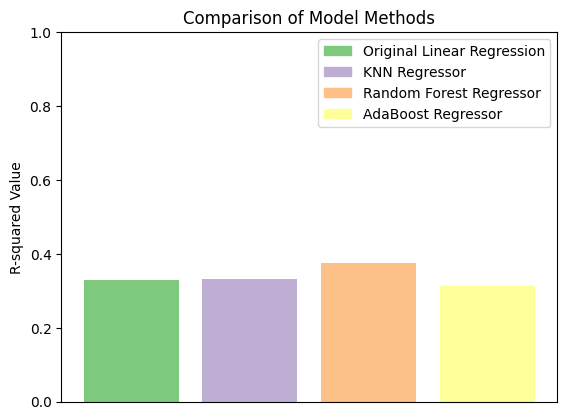

In [6]:
df = pd.DataFrame(
    {'Model': ['Original Linear Regression', 'KNN Regressor', 'Random Forest Regressor', 'AdaBoost Regressor'],
    'R2_Score': [0.33, knn_r2, randomforest_r2, adaboost_r2]
})

models = {'Original Linear Regression':'#7fc97f', 'KNN Regressor':'#beaed4', 'Random Forest Regressor':'#fdc086', 'AdaBoost Regressor':'#ffff99'}         
labels = list(models.keys())
handles = [plt.Rectangle((0,0),1,1, color=models[label]) for label in labels]
bars = plt.bar(df['Model'], df['R2_Score'], color = ['#7fc97f', '#beaed4', '#fdc086', '#ffff99'], label=False)
plt.legend(handles, labels)
plt.xticks([])
plt.ylabel('R-squared Value')
plt.title('Comparison of Model Methods')
plt.ylim(0, 1.0)